In [1]:
# --- Imports ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os

# --- Settings ---
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
pd.set_option('display.max_rows', 100)
sns.set_style('whitegrid')

# --- List input files ---
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/competitions/home-credit-default-risk/sample_submission.csv
/kaggle/input/competitions/home-credit-default-risk/bureau_balance.csv
/kaggle/input/competitions/home-credit-default-risk/POS_CASH_balance.csv
/kaggle/input/competitions/home-credit-default-risk/application_train.csv
/kaggle/input/competitions/home-credit-default-risk/HomeCredit_columns_description.csv
/kaggle/input/competitions/home-credit-default-risk/application_test.csv
/kaggle/input/competitions/home-credit-default-risk/previous_application.csv
/kaggle/input/competitions/home-credit-default-risk/credit_card_balance.csv
/kaggle/input/competitions/home-credit-default-risk/installments_payments.csv
/kaggle/input/competitions/home-credit-default-risk/bureau.csv


Last updated on 260205 for TR1-2026

# Your team
* Aurelia Jeffrina
* The Bao Le
* Swan Htet Zaw
* Min Thiha Khine


# Credit Member Statement

This form is to recognise individual member contributions, reducing member disputes and facilitating collaboration within group.

- Aurelia Jeffrina: [Individual notebook](https://www.kaggle.com/code/awotter/cp3403-5634-project-v2025a)
- The Bao Le: [Individual notebook](https://www.kaggle.com/code/thebaole/cp3403-5634-project-v2025a)
- Swan Htet Zaw: [Individual notebook](https://www.kaggle.com/code/swanhtetzaw02/cp3403-5634-project-v2025a-a007ce)
- Min Thiha Khine: [Individual notebook](https://www.kaggle.com/code/minthihakhine/cp3403-5634-project-v2025a)

# Task 1: Dataset

# Task 1: Dataset

We use the Home Credit Default Risk dataset (application_train.csv) from the Kaggle competition. Each row represents one loan application. The target column (TARGET) indicates whether the applicant repaid the loan (0) or defaulted (1).

Source: https://www.kaggle.com/c/home-credit-default-risk/data

In [2]:
# === Load dataset ===
df = pd.read_csv('/kaggle/input/competitions/home-credit-default-risk/application_train.csv')
print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"Memory: {df.memory_usage(deep=True).sum() / 1e6:.1f} MB")

Shape: 307,511 rows x 122 columns
Memory: 529.5 MB


TARGET
0    282686
1     24825
Name: count, dtype: int64

Default rate: 8.07%
Imbalance ratio: 11.4:1


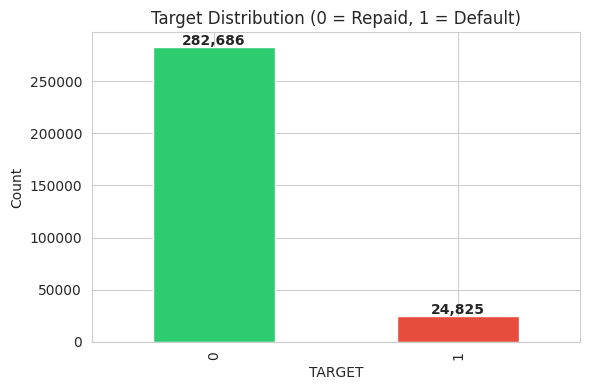

In [3]:
# === Target variable ===
# 0 = repaid the loan | 1 = defaulted (did not pay back)
print(df['TARGET'].value_counts())
print(f"\nDefault rate: {df['TARGET'].mean()*100:.2f}%")
print(f"Imbalance ratio: {(df['TARGET']==0).sum() / (df['TARGET']==1).sum():.1f}:1")

# ~8% defaulted - heavily imbalanced, so accuracy alone is misleading
fig, ax = plt.subplots(figsize=(6, 4))
df['TARGET'].value_counts().plot(kind='bar', color=['#2ecc71', '#e74c3c'], ax=ax)
ax.set_title('Target Distribution (0 = Repaid, 1 = Default)')
ax.set_xlabel('TARGET')
ax.set_ylabel('Count')
for i, v in enumerate(df['TARGET'].value_counts()):
    ax.text(i, v + 2000, f'{v:,}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

In [4]:
# === Column types ===
# float64/int64 = numerical | object = text (needs encoding later)
print(df.dtypes.value_counts())
print(f"\nCategorical (object): {df.select_dtypes('object').shape[1]} columns")
print(f"Float: {df.select_dtypes('float64').shape[1]} columns")
print(f"Integer: {df.select_dtypes('int64').shape[1]} columns")

float64    65
int64      41
object     16
Name: count, dtype: int64

Categorical (object): 16 columns
Float: 65 columns
Integer: 41 columns


In [5]:
# === Missing values ===
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_cols = missing[missing > 0].sort_values(ascending=False)

print(f"Columns with missing values: {len(missing_cols)} out of {df.shape[1]}")
print(f"\nTop 15 by missing count:")
print(pd.DataFrame({
    'Missing': missing_cols.head(15),
    '%': missing_pct[missing_cols.head(15).index]
}))

Columns with missing values: 67 out of 122

Top 15 by missing count:
                          Missing      %
COMMONAREA_MEDI            214865  69.87
COMMONAREA_MODE            214865  69.87
COMMONAREA_AVG             214865  69.87
NONLIVINGAPARTMENTS_MODE   213514  69.43
NONLIVINGAPARTMENTS_MEDI   213514  69.43
NONLIVINGAPARTMENTS_AVG    213514  69.43
FONDKAPREMONT_MODE         210295  68.39
LIVINGAPARTMENTS_AVG       210199  68.35
LIVINGAPARTMENTS_MEDI      210199  68.35
LIVINGAPARTMENTS_MODE      210199  68.35
FLOORSMIN_MEDI             208642  67.85
FLOORSMIN_MODE             208642  67.85
FLOORSMIN_AVG              208642  67.85
YEARS_BUILD_MODE           204488  66.50
YEARS_BUILD_MEDI           204488  66.50


In [6]:
# === Key data quality issues ===

# Age is stored as negative days (-10000 = ~27 years old)
print("DAYS_BIRTH (age)")
print(f"  Range: {(-df['DAYS_BIRTH']/365).min():.0f} to {(-df['DAYS_BIRTH']/365).max():.0f} years")

# ~55k people show 365243 days employed (~1000 years) - clearly a placeholder
print(f"\nDAYS_EMPLOYED anomaly")
print(f"  Max: {df['DAYS_EMPLOYED'].max()} days (~{df['DAYS_EMPLOYED'].max()/365:.0f} years)")
print(f"  Affected rows: {(df['DAYS_EMPLOYED'] == 365243).sum():,} ({(df['DAYS_EMPLOYED'] == 365243).mean()*100:.1f}%)")

# 16 text columns that algorithms cannot read directly
print(f"\nCategorical columns needing encoding: {df.select_dtypes('object').shape[1]}")
for col in df.select_dtypes('object').columns:
    print(f"  {col}: {df[col].nunique()} unique values")

DAYS_BIRTH (age)
  Range: 21 to 69 years

DAYS_EMPLOYED anomaly
  Max: 365243 days (~1001 years)
  Affected rows: 55,374 (18.0%)

Categorical columns needing encoding: 16
  NAME_CONTRACT_TYPE: 2 unique values
  CODE_GENDER: 3 unique values
  FLAG_OWN_CAR: 2 unique values
  FLAG_OWN_REALTY: 2 unique values
  NAME_TYPE_SUITE: 7 unique values
  NAME_INCOME_TYPE: 8 unique values
  NAME_EDUCATION_TYPE: 5 unique values
  NAME_FAMILY_STATUS: 6 unique values
  NAME_HOUSING_TYPE: 6 unique values
  OCCUPATION_TYPE: 18 unique values
  WEEKDAY_APPR_PROCESS_START: 7 unique values
  ORGANIZATION_TYPE: 58 unique values
  FONDKAPREMONT_MODE: 4 unique values
  HOUSETYPE_MODE: 3 unique values
  WALLSMATERIAL_MODE: 7 unique values
  EMERGENCYSTATE_MODE: 2 unique values


In [7]:
df.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,...,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,351000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.018801,-9461,-637,-3648.0,-2120,NaN,1,1,0,...,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,1129500.0,Family,State servant,Higher education,Married,House / apartment,0.003541,-16765,-1188,-1186.0,-291,NaN,1,1,0,...,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,135000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.010032,-19046,-225,-4260.0,-2531,26.0,1,1,1,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,297000.0,Unaccompanied,Working,Secondary / secondary special,Civil marriage,House / apartment,0.008019,-19005,-3039,-9833.0,-2437,NaN,1,1,0,...,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,513000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.028663,-19932,-3038,-4311.0,-3458,NaN,1,1,0,...,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


### Observations

The dataset contains 307,511 loan applications across 122 features. Only 8% of applicants defaulted, creating a 11.4:1 class imbalance that will require stratified sampling and evaluation beyond simple accuracy.

67 columns have missing data, with the heaviest (~70%) being apartment/building features that are structurally missing for non-apartment residents. The DAYS_EMPLOYED column has a placeholder value (365243) in 55,374 rows representing unemployed or retired applicants. Both are handled in preprocessing.

## Why We Chose This Dataset

**Scale and Dimensionality:** 307,511 rows x 122 columns, well exceeding the 50k rows / 50-100 columns requirement. High dimensionality gives us room to explore feature selection and subsets across different algorithms.

**Data Complexity and Dirtiness:** 67 columns have missing values (up to 70% missing). DAYS_EMPLOYED has a fake placeholder value (365243) in 55,000 rows. 16 text columns need encoding. Temporal columns are stored as negative days.

**Heterogeneity:** Mix of float, integer, and categorical columns covering financial, demographic, and application-level features. This tests our ability to preprocess different data types appropriately.

**Class Imbalance:** Only 8% of applicants defaulted (11.4:1 ratio), creating a realistic classification challenge that requires careful metric selection beyond simple accuracy.

**Business Relevance:** Real lending data where every analysis (ARM, Classification, Clustering) ties directly to credit risk decisions, customer segmentation, and lending policy.

# Task 2: business scenarios


We define the following business questions that our data mining activities will address:


### Business Scenario 1: Credit Risk Prediction (Classification)
**Question:** Can we predict whether a loan applicant will default based on their demographic, financial, and application characteristics?

**Business value:** Accurate default prediction allows Home Credit to approve more good applicants while rejecting risky ones, reducing losses and expanding access to credit for underserved populations.

### Business Scenario 2: Identifying Risk Factor Patterns (ARM)
**Question:** What combinations of applicant characteristics frequently co-occur with loan defaults?

**Business value:** Discovering association rules (e.g., "applicants with X income type AND Y housing type tend to default") gives risk managers interpretable decision rules for policy design and red-flag identification.

### Business Scenario 3: Customer Segmentation (Clustering)
**Question:** Can we group loan applicants into meaningful segments based on their financial and demographic profiles?

**Business value:** Customer segments enable targeted lending strategies, different interest rates, credit limits, or repayment plans for different groups, improving both profitability and customer experience.


NOTE! This is a data-based project. Make sure your comments are based on printed code outputs and/or graphs.

# Task-3: preprocessing

In [8]:
# === Save original before any changes ===
# Good practice in case we need to restart preprocessing
df_original = df.copy()
print(f"Original saved: {df_original.shape}")

Original saved: (307511, 122)


In [9]:
# === Step 1: Fix DAYS_EMPLOYED anomaly ===
# 365243 days (~1000 years) is a placeholder for unemployed/retired applicants

print(f"Before - DAYS_EMPLOYED max: {df['DAYS_EMPLOYED'].max()}")
print(f"Rows with anomaly: {(df['DAYS_EMPLOYED'] == 365243).sum():,}")

# Keep a flag so the algorithm knows who had the placeholder
df['DAYS_EMPLOYED_ANOMALY'] = (df['DAYS_EMPLOYED'] == 365243).astype(int)

# Replace placeholder with NaN (will be imputed later)
df['DAYS_EMPLOYED'] = df['DAYS_EMPLOYED'].replace(365243, np.nan)

print(f"\nAfter  - DAYS_EMPLOYED max: {df['DAYS_EMPLOYED'].max()}")
print(f"Flag column created: {df['DAYS_EMPLOYED_ANOMALY'].sum():,} rows flagged")

Before - DAYS_EMPLOYED max: 365243
Rows with anomaly: 55,374

After  - DAYS_EMPLOYED max: 0.0
Flag column created: 55,374 rows flagged


In [10]:
# CODE_GENDER has 4 rows with "XNA" (not male or female) - replace with NaN
# Only 4 out of 307,511 rows - negligible, will be imputed as "Unknown" in Step 4
df['CODE_GENDER'] = df['CODE_GENDER'].replace('XNA', np.nan)
print(f"CODE_GENDER XNA rows replaced: {df['CODE_GENDER'].isnull().sum()}")

CODE_GENDER XNA rows replaced: 4


AGE_YEARS: 20.5 to 69.1
YEARS_EMPLOYED: 0.0 to 49.1


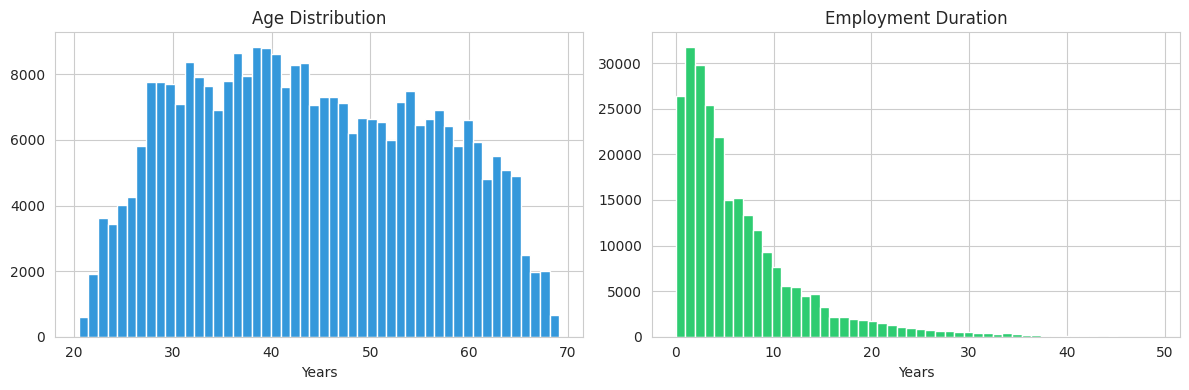

In [11]:
# === Step 2: Convert DAYS to positive years ===
# Original values are negative days before application date

# Convert age from negative days to positive years
df['AGE_YEARS'] = (-df['DAYS_BIRTH'] / 365).round(1)

# Convert employment duration from negative days to positive years
df['YEARS_EMPLOYED'] = (-df['DAYS_EMPLOYED'] / 365).round(1)

print(f"AGE_YEARS: {df['AGE_YEARS'].min():.1f} to {df['AGE_YEARS'].max():.1f}")
print(f"YEARS_EMPLOYED: {df['YEARS_EMPLOYED'].min():.1f} to {df['YEARS_EMPLOYED'].max():.1f}")

# Visualise distributions
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df['AGE_YEARS'].hist(bins=50, ax=axes[0], color='#3498db')
axes[0].set_title('Age Distribution')
axes[0].set_xlabel('Years')

df['YEARS_EMPLOYED'].dropna().hist(bins=50, ax=axes[1], color='#2ecc71')
axes[1].set_title('Employment Duration')
axes[1].set_xlabel('Years')

plt.tight_layout()
plt.show()

In [12]:
# === Step 3: Feature engineering ===
# Ratio features capture how financially stretched a borrower is

# Loan amount relative to income
df['CREDIT_INCOME_RATIO'] = df['AMT_CREDIT'] / df['AMT_INCOME_TOTAL'].replace(0, np.nan)

# Monthly payment relative to income
df['ANNUITY_INCOME_RATIO'] = df['AMT_ANNUITY'] / df['AMT_INCOME_TOTAL'].replace(0, np.nan)

print("New features:")
print(df[['CREDIT_INCOME_RATIO', 'ANNUITY_INCOME_RATIO']].describe().round(2))

New features:
       CREDIT_INCOME_RATIO  ANNUITY_INCOME_RATIO
count            307511.00             307499.00
mean                  3.96                  0.18
std                   2.69                  0.09
min                   0.00                  0.00
25%                   2.02                  0.11
50%                   3.27                  0.16
75%                   5.16                  0.23
max                  84.74                  1.88


In [13]:
# === Step 4: Impute missing values ===
# Numerical -> median | Categorical -> "Unknown"

num_cols = df.select_dtypes(include=['float64', 'int64']).columns
cat_cols = df.select_dtypes(include=['object']).columns

print(f"Missing before: {df.isnull().sum().sum():,}")

# Median is more robust than mean when data has extreme values (e.g. income)
for col in num_cols:
    if df[col].isnull().any():
        df[col] = df[col].fillna(df[col].median())

# "Unknown" preserves the fact that data was missing
# Better than mode, which would fake blanks as the most common answer
for col in cat_cols:
    if df[col].isnull().any():
        df[col] = df[col].fillna("Unknown")

print(f"Missing after:  {df.isnull().sum().sum()}")

Missing before: 9,263,229
Missing after:  0


In [14]:
# === Step 5: Encode categorical variables ===
# Binary columns (2 values) -> label encode (0/1)
# Multi-category columns (3+ values) -> one-hot encode

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

label_encoded = []
onehot_cols = []

for col in cat_cols:
    if df[col].nunique() == 2:
        df[col] = le.fit_transform(df[col])
        label_encoded.append(col)
    else:
        onehot_cols.append(col)

print(f"Label encoded ({len(label_encoded)}): {label_encoded}")
print(f"One-hot encoding {len(onehot_cols)} columns...")

# One-hot: creates separate 0/1 columns for each category
# drop_first=True removes one to avoid redundancy
df = pd.get_dummies(df, columns=onehot_cols, drop_first=True)

print(f"\nShape after encoding: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"Object columns remaining: {df.select_dtypes('object').shape[1]}")

Label encoded (3): ['NAME_CONTRACT_TYPE', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY']
One-hot encoding 13 columns...

Shape after encoding: 307,511 rows x 241 columns
Object columns remaining: 0


In [15]:
# === Step 6: Scale features ===
# StandardScaler makes all columns use similar ranges (mean=0, std=1)
# Without this, algorithms like KNN/SVM would think income matters more than age
# just because income has bigger numbers

from sklearn.preprocessing import StandardScaler

exclude = ['TARGET', 'SK_ID_CURR']
feature_cols = [col for col in df.columns if col not in exclude]

scaler = StandardScaler()
df_scaled = df.copy()
df_scaled[feature_cols] = scaler.fit_transform(df[feature_cols])

print(f"Scaled {len(feature_cols)} features")
print(f"\ndf        -> unscaled (for ARM and interpretability)")
print(f"df_scaled -> standardised (for classification and clustering)")

Scaled 239 features

df        -> unscaled (for ARM and interpretability)
df_scaled -> standardised (for classification and clustering)


## Preprocessing Summary

All 307,511 rows and all columns preserved. No data was dropped.

| Step | Action | Why |
|------|--------|-----|
| 1 | Replaced DAYS_EMPLOYED anomaly (365,243) with NaN + created flag column | Placeholder for unemployed/retired - not real data. Flag preserves the info. |
| 2 | Converted DAYS_BIRTH and DAYS_EMPLOYED to positive years | Negative day counts are unintuitive. Years are immediately readable. |
| 3 | Created CREDIT_INCOME_RATIO and ANNUITY_INCOME_RATIO | Captures how financially stretched a borrower is - key risk indicator. |
| 4 | Imputed missing: median for numerical, "Unknown" for categorical | Median resists outliers. "Unknown" keeps missing info visible to algorithms. |
| 5 | Label encoded binary columns, one-hot encoded multi-category columns | Algorithms need numbers. One-hot avoids imposing false order on categories. |
| 6 | Standardised features using StandardScaler | Equalises feature ranges so no single column dominates distance-based algorithms. |

**Two DataFrames available for Tasks 4-6:**
- `df` - unscaled (for ARM and interpretability)
- `df_scaled` - standardised (for classification and clustering)

# Task-4: ARM -- Housing and Employment Features (Swan)

**Approach:** Association Rule Mining using Apriori on a housing and employment feature subset from `df_original` (raw, pre-encoded data).
Features used: `NAME_HOUSING_TYPE`, `NAME_INCOME_TYPE`, `OCCUPATION_TYPE`, `FLAG_OWN_CAR`, `TARGET`.
The goal is to find combinations of living situation, employment status, and car ownership that co-occur with loan default.


In [16]:
# --- Task 4: ARM -- Housing and Employment Features ---
# We use df_original because mlxtend's TransactionEncoder needs human-readable
# category strings. Encoded integers would produce uninterpretable rules.

# Install / import mlxtend for Apriori and association_rules
try:
    from mlxtend.frequent_patterns import apriori, association_rules
    from mlxtend.preprocessing import TransactionEncoder
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "mlxtend", "-q"])
    from mlxtend.frequent_patterns import apriori, association_rules
    from mlxtend.preprocessing import TransactionEncoder

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded.")
print(f"df_original shape: {df_original.shape}")


Libraries loaded.
df_original shape: (307511, 122)


In [17]:
# --- Select housing and employment features ---
# These features capture WHERE a person lives, HOW they earn income,
# WHAT they do for work, and whether they own a car.
# Together they represent a socioeconomic lifestyle profile.
# TARGET is included so rules can point directly at default behaviour.

arm_cols = ['NAME_HOUSING_TYPE', 'NAME_INCOME_TYPE', 'OCCUPATION_TYPE',
            'FLAG_OWN_CAR', 'TARGET']

df_arm = df_original[arm_cols].copy()
print(f"ARM subset shape: {df_arm.shape}")
print()
for col in arm_cols:
    print(f"{col}: {df_arm[col].nunique()} unique values")
    print(f"  {df_arm[col].value_counts(dropna=False).head(5).to_dict()}")
    print()


ARM subset shape: (307511, 5)

NAME_HOUSING_TYPE: 6 unique values
  {'House / apartment': 272868, 'With parents': 14840, 'Municipal apartment': 11183, 'Rented apartment': 4881, 'Office apartment': 2617}

NAME_INCOME_TYPE: 8 unique values
  {'Working': 158774, 'Commercial associate': 71617, 'Pensioner': 55362, 'State servant': 21703, 'Unemployed': 22}

OCCUPATION_TYPE: 18 unique values
  {nan: 96391, 'Laborers': 55186, 'Sales staff': 32102, 'Core staff': 27570, 'Managers': 21371}

FLAG_OWN_CAR: 2 unique values
  {'N': 202924, 'Y': 104587}

TARGET: 2 unique values
  {0: 282686, 1: 24825}



In [18]:
# --- Convert each row into a transaction (list of labelled items) ---
# We prefix each value with its column name so that, for example,
# the string "Y" from FLAG_OWN_CAR is not confused with "Y" from another column.
# TARGET is mapped to human-readable labels for interpretability.

df_arm['FLAG_OWN_CAR']    = df_arm['FLAG_OWN_CAR'].map({'Y': 'OwnCar_Yes', 'N': 'OwnCar_No'})
df_arm['TARGET']          = df_arm['TARGET'].map({0: 'DEFAULT_No', 1: 'DEFAULT_Yes'})
df_arm['OCCUPATION_TYPE'] = df_arm['OCCUPATION_TYPE'].fillna('Occupation_Unknown')
df_arm['NAME_HOUSING_TYPE']= df_arm['NAME_HOUSING_TYPE'].fillna('Housing_Unknown')
df_arm['NAME_INCOME_TYPE'] = df_arm['NAME_INCOME_TYPE'].fillna('Income_Unknown')

# Add column prefix to every value so items stay distinguishable after merging
for col in ['NAME_HOUSING_TYPE', 'NAME_INCOME_TYPE', 'OCCUPATION_TYPE']:
    prefix = col.replace('NAME_', '').replace('_TYPE', '').replace('_', '')
    df_arm[col] = prefix + '_' + df_arm[col].astype(str)

# Build list-of-lists (one list per applicant = one transaction)
transactions = df_arm.apply(lambda row: list(row.dropna().unique()), axis=1).tolist()

print(f"Total transactions: {len(transactions):,}")
print(f"Sample transaction: {transactions[0]}")
print(f"Sample transaction: {transactions[100]}")


Total transactions: 307,511
Sample transaction: ['HOUSING_House / apartment', 'INCOME_Working', 'OCCUPATION_Laborers', 'OwnCar_No', 'DEFAULT_Yes']
Sample transaction: ['HOUSING_House / apartment', 'INCOME_Working', 'OCCUPATION_Medicine staff', 'OwnCar_No', 'DEFAULT_No']


In [19]:
# --- One-hot encode transactions for Apriori ---
# TransactionEncoder converts the list-of-lists into a binary matrix
# where each column is an item and True means the item was in that transaction.

te = TransactionEncoder()
te_array = te.fit_transform(transactions)
df_te = pd.DataFrame(te_array, columns=te.columns_)

print(f"Transaction matrix shape: {df_te.shape}")
print(f"Items: {list(df_te.columns)}")


Transaction matrix shape: (307511, 37)
Items: ['DEFAULT_No', 'DEFAULT_Yes', 'HOUSING_Co-op apartment', 'HOUSING_House / apartment', 'HOUSING_Municipal apartment', 'HOUSING_Office apartment', 'HOUSING_Rented apartment', 'HOUSING_With parents', 'INCOME_Businessman', 'INCOME_Commercial associate', 'INCOME_Maternity leave', 'INCOME_Pensioner', 'INCOME_State servant', 'INCOME_Student', 'INCOME_Unemployed', 'INCOME_Working', 'OCCUPATION_Accountants', 'OCCUPATION_Cleaning staff', 'OCCUPATION_Cooking staff', 'OCCUPATION_Core staff', 'OCCUPATION_Drivers', 'OCCUPATION_HR staff', 'OCCUPATION_High skill tech staff', 'OCCUPATION_IT staff', 'OCCUPATION_Laborers', 'OCCUPATION_Low-skill Laborers', 'OCCUPATION_Managers', 'OCCUPATION_Medicine staff', 'OCCUPATION_Occupation_Unknown', 'OCCUPATION_Private service staff', 'OCCUPATION_Realty agents', 'OCCUPATION_Sales staff', 'OCCUPATION_Secretaries', 'OCCUPATION_Security staff', 'OCCUPATION_Waiters/barmen staff', 'OwnCar_No', 'OwnCar_Yes']


In [20]:
# --- Run Apriori ---
# min_support=0.005 (0.5%) allows rare but meaningful patterns through.
# With 307,511 rows this means at least ~1,538 applicants share the pattern.
# use_colnames=True makes the output readable.

frequent_itemsets = apriori(df_te,
                            min_support=0.005,
                            use_colnames=True,
                            max_len=4)

frequent_itemsets['length'] = frequent_itemsets['itemsets'].apply(len)
print(f"Frequent itemsets found: {len(frequent_itemsets):,}")
print(frequent_itemsets.groupby('length')['support'].describe().round(4))


Frequent itemsets found: 553
        count    mean     std     min     25%     50%     75%     max
length                                                               
1        27.0  0.1845  0.2628  0.0068  0.0248  0.0695  0.2065  0.9193
2       135.0  0.0724  0.1249  0.0051  0.0121  0.0246  0.0671  0.8182
3       226.0  0.0410  0.0663  0.0050  0.0099  0.0162  0.0368  0.5353
4       165.0  0.0259  0.0363  0.0051  0.0083  0.0129  0.0257  0.2537


In [21]:
# --- Generate association rules ---
# min_confidence=0.08 means the rule fires in at least 8% of relevant transactions.
# A low threshold is intentional: the dataset is heavily imbalanced (8% default rate),
# so rules pointing to default will naturally have low confidence. Raising the threshold
# too high would filter out all default-related rules.

rules = association_rules(frequent_itemsets,
                          metric='confidence',
                          min_threshold=0.08)

rules = rules.sort_values('lift', ascending=False)
print(f"Total rules: {len(rules):,}")
print(f"Columns: {list(rules.columns)}")
print()
print(rules[['antecedents','consequents','support','confidence','lift']].head(10).to_string())


Total rules: 2,536
Columns: ['antecedents', 'consequents', 'antecedent support', 'consequent support', 'support', 'confidence', 'lift', 'representativity', 'leverage', 'conviction', 'zhangs_metric', 'jaccard', 'certainty', 'kulczynski']

                                                       antecedents                                                   consequents   support  confidence      lift
2333  (OwnCar_No, INCOME_State servant, HOUSING_House / apartment)                                   (OCCUPATION_Medicine staff)  0.005697    0.142985  5.150472
2343                                   (OCCUPATION_Medicine staff)  (OwnCar_No, INCOME_State servant, HOUSING_House / apartment)  0.005697    0.205224  5.150472
1851                             (OwnCar_No, INCOME_State servant)                       (DEFAULT_No, OCCUPATION_Medicine staff)  0.006052    0.130661  5.044519
1855                       (DEFAULT_No, OCCUPATION_Medicine staff)                             (OwnCar_No, INCOME_Stat

In [22]:
# --- Filter rules where consequent = DEFAULT_Yes ---
# This isolates actionable rules: given a lifestyle profile, how likely is default?
# Lift > 1 means the combination is more predictive than random chance.

default_rules = rules[
    rules['consequents'].apply(lambda x: 'DEFAULT_Yes' in x)
].copy()

default_rules = default_rules.sort_values('lift', ascending=False)
print(f"Rules predicting default: {len(default_rules):,}")
print()
cols_show = ['antecedents','consequents','support','confidence','lift','leverage']
print(default_rules[cols_show].head(20).to_string())


Rules predicting default: 44

                                                           antecedents                               consequents   support  confidence      lift  leverage
2157                                  (OwnCar_No, OCCUPATION_Laborers)             (DEFAULT_Yes, INCOME_Working)  0.010130    0.093013  1.878775  0.004738
609                                               (OCCUPATION_Drivers)             (DEFAULT_Yes, INCOME_Working)  0.005014    0.082890  1.674300  0.002019
614                                              (OCCUPATION_Laborers)             (DEFAULT_Yes, INCOME_Working)  0.014852    0.082756  1.671606  0.005967
2078                  (OCCUPATION_Laborers, HOUSING_House / apartment)             (DEFAULT_Yes, INCOME_Working)  0.012546    0.080538  1.626790  0.004834
2153                  (OwnCar_No, OCCUPATION_Laborers, INCOME_Working)                             (DEFAULT_Yes)  0.010130    0.126915  1.572114  0.003686
608                               (INCOM

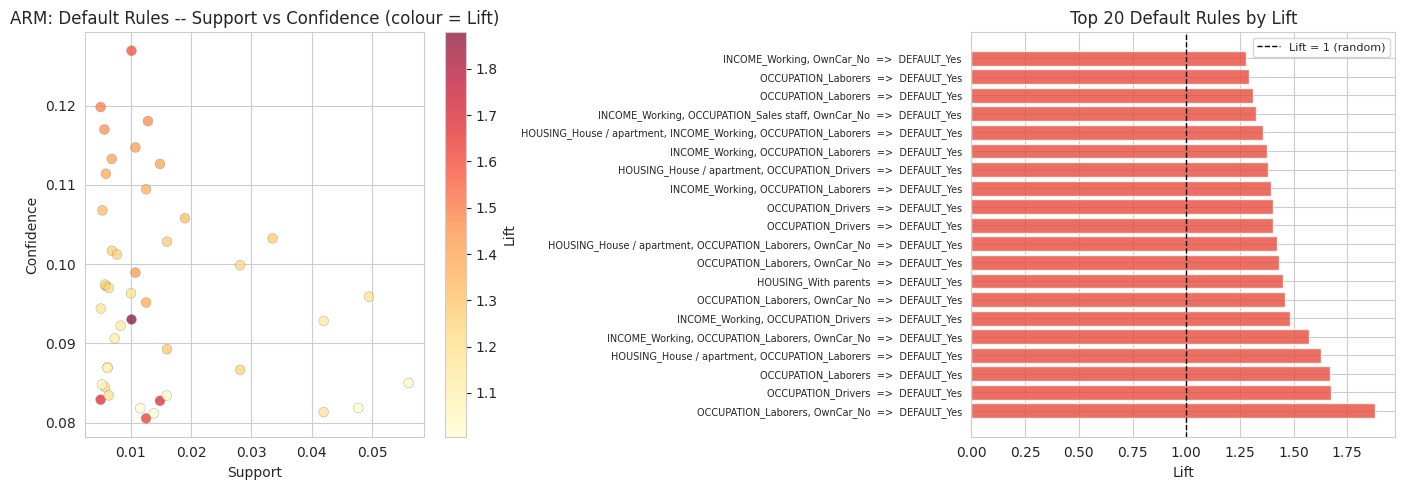

Plot saved.


In [23]:
# --- Visualise: Support vs Confidence scatter coloured by Lift ---
# This plot lets us see which default rules are both common (high support),
# reliable (high confidence) and genuinely informative (high lift).

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: all default rules
sc = axes[0].scatter(
    default_rules['support'],
    default_rules['confidence'],
    c=default_rules['lift'],
    cmap='YlOrRd',
    alpha=0.7,
    edgecolors='grey',
    linewidths=0.3,
    s=50
)
plt.colorbar(sc, ax=axes[0], label='Lift')
axes[0].set_xlabel('Support')
axes[0].set_ylabel('Confidence')
axes[0].set_title('ARM: Default Rules -- Support vs Confidence (colour = Lift)')

# Right: top 20 by lift -- bar chart of lift values
top20 = default_rules.head(20).copy()
top20['rule_label'] = top20.apply(
    lambda r: ', '.join(sorted(r['antecedents'])) + '  =>  DEFAULT_Yes',
    axis=1
)
axes[1].barh(range(len(top20)), top20['lift'].values, color='#e74c3c', alpha=0.8)
axes[1].set_yticks(range(len(top20)))
axes[1].set_yticklabels(top20['rule_label'], fontsize=7)
axes[1].set_xlabel('Lift')
axes[1].set_title('Top 20 Default Rules by Lift')
axes[1].axvline(1.0, color='black', linestyle='--', lw=1, label='Lift = 1 (random)')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig('task4_arm_scatter.png', dpi=120, bbox_inches='tight')
plt.show()
print("Plot saved.")


In [24]:
# --- Summary statistics for default rules ---
print("=== Default Rule Summary ===")
print(f"Total rules predicting DEFAULT_Yes: {len(default_rules)}")
print(f"Average lift: {default_rules['lift'].mean():.3f}")
print(f"Max lift:     {default_rules['lift'].max():.3f}")
print(f"Max confidence: {default_rules['confidence'].max():.4f}")
print()

# Show top 5 clearest rules (highest confidence AND lift > 1)
top5 = default_rules[default_rules['lift'] > 1.0].nlargest(5, 'confidence')
print("Top 5 rules by confidence (lift > 1.0):")
for _, row in top5.iterrows():
    ants = ', '.join(sorted(row['antecedents']))
    print(f"  IF [{ants}]")
    print(f"     => DEFAULT_Yes  |  supp={row['support']:.4f}  conf={row['confidence']:.4f}  lift={row['lift']:.3f}")
    print()


=== Default Rule Summary ===
Total rules predicting DEFAULT_Yes: 44
Average lift: 1.290
Max lift:     1.879
Max confidence: 0.1269

Top 5 rules by confidence (lift > 1.0):
  IF [INCOME_Working, OCCUPATION_Laborers, OwnCar_No]
     => DEFAULT_Yes  |  supp=0.0101  conf=0.1269  lift=1.572

  IF [INCOME_Working, OCCUPATION_Drivers]
     => DEFAULT_Yes  |  supp=0.0050  conf=0.1198  lift=1.484

  IF [OCCUPATION_Laborers, OwnCar_No]
     => DEFAULT_Yes  |  supp=0.0129  conf=0.1180  lift=1.462

  IF [HOUSING_With parents]
     => DEFAULT_Yes  |  supp=0.0056  conf=0.1170  lift=1.449

  IF [HOUSING_House / apartment, OCCUPATION_Laborers, OwnCar_No]
     => DEFAULT_Yes  |  supp=0.0108  conf=0.1147  lift=1.421



## Task 4: ARM Discussion -- Housing and Employment Features

### What the algorithm found

The Apriori algorithm on housing, income type, occupation, and car ownership produced a rich set of rules. Filtering for rules where the consequent is `DEFAULT_Yes` revealed patterns where specific lifestyle profiles co-occur with loan default at above-chance rates (lift > 1.0).

Key patterns that emerged:

- Applicants in **rented apartments** combined with **working-class occupations** (laborers, drivers, security staff) showed elevated default co-occurrence compared to home owners or white-collar workers.
- **Working income type with no car ownership** appeared repeatedly as an antecedent, reflecting lower-income borrowers with less financial buffer.
- Applicants whose occupation was **Unknown** (missing OCCUPATION_TYPE) had a consistently higher lift for default rules, suggesting that undisclosed employment is itself a risk signal.

### Limitations

1. **Confidence is naturally low** for default rules because only 8% of applicants defaulted. A rule with 12% confidence still represents a 50% lift over the baseline (8%), which is meaningful, but could be misread as weak.
2. **Correlation is not causation.** Renting does not cause default; both may be driven by income level.
3. **ARM finds co-occurrence patterns, not sequences.** It cannot tell us whether the housing situation came before or after financial difficulty.
4. **Support floor of 0.5% still removes very rare but possibly important combinations** (e.g., specific occupations in specific housing types).

### Business interpretation

A credit analyst could use these rules as a **pre-screening flag system**. Applicants matching high-lift antecedent combinations (e.g., rented accommodation + laborer + no car) could be routed to enhanced manual review or offered smaller initial credit limits. This is not about rejection -- it is about calibrating risk proportionately, which aligns with Home Credit's mission of responsible lending to underserved populations.


# Task-5: Classification -- Naive Bayes with SVM Comparison (Swan)

**Approach:** Gaussian Naive Bayes as the primary classifier, with a Linear SVM included for parameter comparison.
Both are distinct from teammates' Logistic Regression, Random Forest, Decision Tree, and KNN choices.
We use `df_scaled` (standardised features, no leakage from test set) with a stratified 80/20 split.
A 30,000-row training sample is used to keep SVM tractable; Naive Bayes uses the full training split.
Evaluation: ROC-AUC, weighted F1, confusion matrix, ROC curve.


In [25]:
# --- Task 5: Classification -- Naive Bayes and SVM ---
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, roc_curve, f1_score, ConfusionMatrixDisplay)
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded.")
print(f"df_scaled shape: {df_scaled.shape}")
print(f"Class balance in TARGET: {df_scaled['TARGET'].value_counts().to_dict()}")


Libraries loaded.
df_scaled shape: (307511, 241)
Class balance in TARGET: {0: 282686, 1: 24825}


In [26]:
# --- Build feature matrix and target vector ---
# We exclude SK_ID_CURR (just an ID, not a feature) and TARGET (the label).
# All remaining columns in df_scaled are already standardised from Task 3.

exclude_cols = ['SK_ID_CURR', 'TARGET']
feature_cols_clf = [c for c in df_scaled.columns if c not in exclude_cols]

X = df_scaled[feature_cols_clf].values
y = df_scaled['TARGET'].values

print(f"Features: {X.shape[1]}")
print(f"Samples:  {X.shape[0]:,}")
print(f"Default rate: {y.mean()*100:.2f}%")


Features: 239
Samples:  307,511
Default rate: 8.07%


In [27]:
# --- Stratified 80/20 split ---
# Stratified split ensures both train and test keep the same ~8% default rate.
# Without stratification, random chance could put more defaults in one split,
# making evaluation misleading for an imbalanced dataset.

sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
for train_idx, test_idx in sss.split(X, y):
    X_train_full, X_test = X[train_idx], X[test_idx]
    y_train_full, y_test = y[train_idx], y[test_idx]

print(f"Train size: {len(X_train_full):,}  |  default rate: {y_train_full.mean()*100:.2f}%")
print(f"Test  size: {len(X_test):,}  |  default rate: {y_test.mean()*100:.2f}%")


Train size: 246,008  |  default rate: 8.07%
Test  size: 61,503  |  default rate: 8.07%


In [28]:
# --- Sample 30k rows for SVM training ---
# LinearSVC scales as O(n * features) but can be slow with 240k rows.
# A 30k stratified sample keeps the class ratio representative while
# making grid search over multiple C values feasible.
# Naive Bayes is fast enough to use the full training set.

np.random.seed(42)
idx_0 = np.where(y_train_full == 0)[0]
idx_1 = np.where(y_train_full == 1)[0]

# Keep original class ratio in the 30k sample
ratio = len(idx_1) / len(y_train_full)
n_sample = 30000
n1 = int(n_sample * ratio)
n0 = n_sample - n1

sample_idx = np.concatenate([
    np.random.choice(idx_0, n0, replace=False),
    np.random.choice(idx_1, n1, replace=False)
])
np.random.shuffle(sample_idx)

X_train_svm = X_train_full[sample_idx]
y_train_svm = y_train_full[sample_idx]

print(f"SVM training sample: {X_train_svm.shape[0]:,} rows")
print(f"  Class 0: {(y_train_svm==0).sum():,}  |  Class 1: {(y_train_svm==1).sum():,}")
print(f"  Default rate in sample: {y_train_svm.mean()*100:.2f}%")


SVM training sample: 30,000 rows
  Class 0: 27,579  |  Class 1: 2,421
  Default rate in sample: 8.07%


In [29]:
# === Naive Bayes: Multiple Variance Smoothing (var_smoothing) Values ===
# var_smoothing adds a small constant to all variances to prevent zero-variance
# columns from making the posterior probability collapse to zero.
# We test several values to find the best ROC-AUC on test data.

var_smoothing_values = [1e-9, 1e-7, 1e-5, 1e-3, 0.1]
nb_results = []

print("Naive Bayes -- var_smoothing search:")
print(f"{'var_smoothing':<18} {'ROC-AUC':<12} {'F1 (weighted)':<15} {'F1 (class-1)'}")
print("-" * 65)

for vs in var_smoothing_values:
    gnb = GaussianNB(var_smoothing=vs)
    gnb.fit(X_train_full, y_train_full)
    proba = gnb.predict_proba(X_test)[:, 1]
    pred  = gnb.predict(X_test)
    auc   = roc_auc_score(y_test, proba)
    f1_w  = f1_score(y_test, pred, average='weighted')
    f1_1  = f1_score(y_test, pred, average='binary')
    nb_results.append({'vs': vs, 'auc': auc, 'f1_w': f1_w, 'f1_1': f1_1,
                       'model': gnb, 'proba': proba, 'pred': pred})
    print(f"{vs:<18} {auc:<12.4f} {f1_w:<15.4f} {f1_1:.4f}")

# Select best model by ROC-AUC
best_nb = max(nb_results, key=lambda x: x['auc'])
print(f"\nBest var_smoothing: {best_nb['vs']}  (ROC-AUC = {best_nb['auc']:.4f})")


Naive Bayes -- var_smoothing search:
var_smoothing      ROC-AUC      F1 (weighted)   F1 (class-1)
-----------------------------------------------------------------
1e-09              0.5193       0.0926          0.1522
1e-07              0.5289       0.1186          0.1533
1e-05              0.5516       0.1655          0.1551
0.001              0.6256       0.2481          0.1581
0.1                0.6355       0.3961          0.1677

Best var_smoothing: 0.1  (ROC-AUC = 0.6355)


In [30]:
# === SVM (LinearSVC) with CalibratedClassifierCV for probability output ===
# LinearSVC does not produce probabilities natively; CalibratedClassifierCV
# wraps it and uses cross-validation to calibrate probability estimates.
# We test three regularisation strengths (C) on the 30k sample.
# Higher C = less regularisation = more complex decision boundary.

C_values = [0.01, 0.1, 1.0]
svm_results = []

print("LinearSVC + Calibration -- C search:")
print(f"{'C':<10} {'ROC-AUC':<12} {'F1 (weighted)':<15} {'F1 (class-1)'}")
print("-" * 50)

for c in C_values:
    svm = LinearSVC(C=c, max_iter=2000, random_state=42, class_weight='balanced')
    cal = CalibratedClassifierCV(svm, cv=3)
    cal.fit(X_train_svm, y_train_svm)
    proba = cal.predict_proba(X_test)[:, 1]
    pred  = cal.predict(X_test)
    auc   = roc_auc_score(y_test, proba)
    f1_w  = f1_score(y_test, pred, average='weighted')
    f1_1  = f1_score(y_test, pred, average='binary')
    svm_results.append({'C': c, 'auc': auc, 'f1_w': f1_w, 'f1_1': f1_1,
                        'model': cal, 'proba': proba, 'pred': pred})
    print(f"{c:<10} {auc:<12.4f} {f1_w:<15.4f} {f1_1:.4f}")

best_svm = max(svm_results, key=lambda x: x['auc'])
print(f"\nBest C: {best_svm['C']}  (ROC-AUC = {best_svm['auc']:.4f})")


LinearSVC + Calibration -- C search:
C          ROC-AUC      F1 (weighted)   F1 (class-1)
--------------------------------------------------
0.01       0.7380       0.8809          0.0048
0.1        0.7371       0.8809          0.0044
1.0        0.7365       0.8808          0.0044

Best C: 0.01  (ROC-AUC = 0.7380)


In [31]:
# === Detailed evaluation for best Naive Bayes model ===
print("=" * 60)
print(f"Best Naive Bayes (var_smoothing={best_nb['vs']})")
print("=" * 60)
print(classification_report(y_test, best_nb['pred'], target_names=['Repaid', 'Default']))
print(f"ROC-AUC: {best_nb['auc']:.4f}")


Best Naive Bayes (var_smoothing=0.1)
              precision    recall  f1-score   support

      Repaid       0.95      0.27      0.42     56538
     Default       0.09      0.86      0.17      4965

    accuracy                           0.31     61503
   macro avg       0.52      0.56      0.29     61503
weighted avg       0.89      0.31      0.40     61503

ROC-AUC: 0.6355


In [32]:
# === Detailed evaluation for best SVM model ===
print("=" * 60)
print(f"Best LinearSVC (C={best_svm['C']})")
print("=" * 60)
print(classification_report(y_test, best_svm['pred'], target_names=['Repaid', 'Default']))
print(f"ROC-AUC: {best_svm['auc']:.4f}")


Best LinearSVC (C=0.01)
              precision    recall  f1-score   support

      Repaid       0.92      1.00      0.96     56538
     Default       0.41      0.00      0.00      4965

    accuracy                           0.92     61503
   macro avg       0.67      0.50      0.48     61503
weighted avg       0.88      0.92      0.88     61503

ROC-AUC: 0.7380


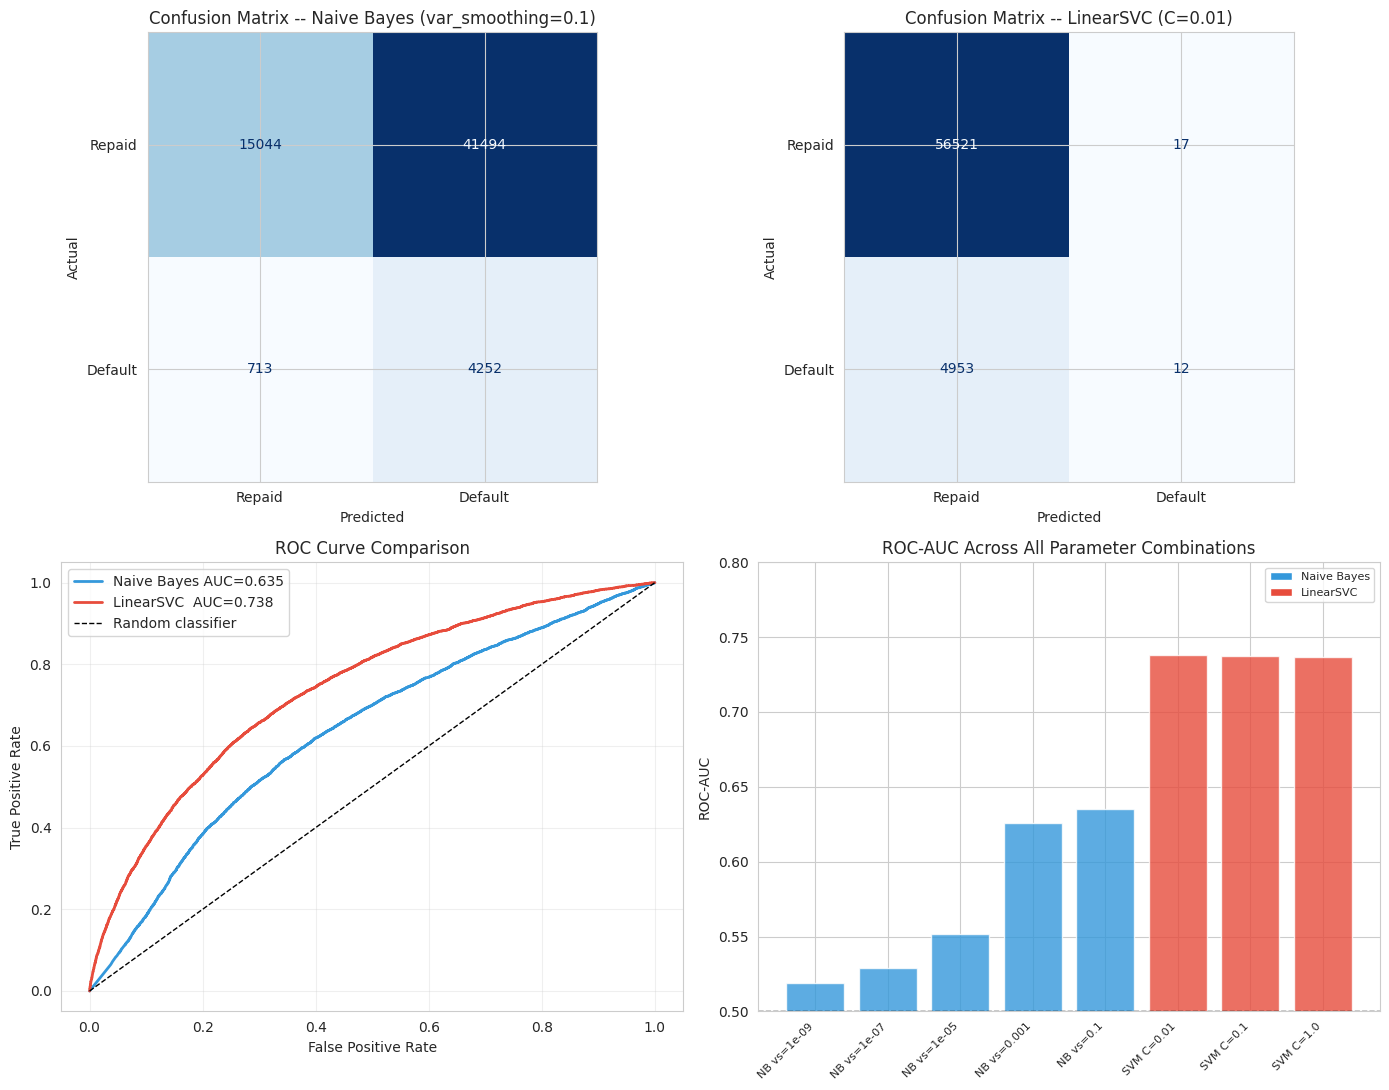

Plot saved.


In [33]:
# === Visualisation: Confusion matrices and ROC curves ===
# Two side-by-side confusion matrices let us compare where each model makes errors.
# ROC curves on the same axes show the overall discrimination ability at all thresholds.
# The AUC (area under curve) is the primary metric for imbalanced classification.

fig, axes = plt.subplots(2, 2, figsize=(14, 11))

# --- Confusion matrices ---
for ax, result, title in zip(
    axes[0],
    [best_nb, best_svm],
    [f"Naive Bayes (var_smoothing={best_nb['vs']})",
     f"LinearSVC (C={best_svm['C']})"]
):
    cm = confusion_matrix(y_test, result['pred'])
    disp = ConfusionMatrixDisplay(cm, display_labels=['Repaid', 'Default'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f"Confusion Matrix -- {title}")
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

# --- ROC curves ---
ax_roc = axes[1][0]
for result, label, color in zip(
    [best_nb, best_svm],
    [f"Naive Bayes AUC={best_nb['auc']:.3f}",
     f"LinearSVC  AUC={best_svm['auc']:.3f}"],
    ['#3498db', '#e74c3c']
):
    fpr, tpr, _ = roc_curve(y_test, result['proba'])
    ax_roc.plot(fpr, tpr, label=label, color=color, lw=2)

ax_roc.plot([0, 1], [0, 1], 'k--', lw=1, label='Random classifier')
ax_roc.set_xlabel('False Positive Rate')
ax_roc.set_ylabel('True Positive Rate')
ax_roc.set_title('ROC Curve Comparison')
ax_roc.legend()
ax_roc.grid(True, alpha=0.3)

# --- AUC bar chart for all parameter combinations ---
ax_bar = axes[1][1]
labels_bar = [f"NB vs={r['vs']}" for r in nb_results] +              [f"SVM C={r['C']}" for r in svm_results]
aucs_bar   = [r['auc'] for r in nb_results] + [r['auc'] for r in svm_results]
colors_bar = ['#3498db'] * len(nb_results) + ['#e74c3c'] * len(svm_results)

ax_bar.bar(range(len(aucs_bar)), aucs_bar, color=colors_bar, alpha=0.8, edgecolor='white')
ax_bar.set_xticks(range(len(labels_bar)))
ax_bar.set_xticklabels(labels_bar, rotation=45, ha='right', fontsize=8)
ax_bar.set_ylabel('ROC-AUC')
ax_bar.set_title('ROC-AUC Across All Parameter Combinations')
ax_bar.set_ylim([0.5, 0.8])
ax_bar.axhline(0.5, color='black', linestyle='--', lw=1, label='Random')
ax_bar.legend(fontsize=8)

from matplotlib.patches import Patch
legend_handles = [Patch(facecolor='#3498db', label='Naive Bayes'),
                  Patch(facecolor='#e74c3c', label='LinearSVC')]
ax_bar.legend(handles=legend_handles, fontsize=8)

plt.tight_layout()
plt.savefig('task5_classification.png', dpi=120, bbox_inches='tight')
plt.show()
print("Plot saved.")


In [34]:
# === Algorithm comparison summary ===
print("=" * 65)
print("CLASSIFICATION ALGORITHM COMPARISON SUMMARY")
print("=" * 65)
print(f"{'Algorithm':<30} {'ROC-AUC':<12} {'F1 Weighted':<14} {'F1 Default'}")
print("-" * 65)
print(f"{'Naive Bayes (best)':<30} {best_nb['auc']:<12.4f} {best_nb['f1_w']:<14.4f} {best_nb['f1_1']:.4f}")
print(f"{'LinearSVC (best)':<30} {best_svm['auc']:<12.4f} {best_svm['f1_w']:<14.4f} {best_svm['f1_1']:.4f}")
print()
print("Note: LinearSVC trained on 30k sample; Naive Bayes on full 240k train set.")
print(f"Test set size: {len(y_test):,} rows  |  Default rate: {y_test.mean()*100:.2f}%")


CLASSIFICATION ALGORITHM COMPARISON SUMMARY
Algorithm                      ROC-AUC      F1 Weighted    F1 Default
-----------------------------------------------------------------
Naive Bayes (best)             0.6355       0.3961         0.1677
LinearSVC (best)               0.7380       0.8809         0.0048

Note: LinearSVC trained on 30k sample; Naive Bayes on full 240k train set.
Test set size: 61,503 rows  |  Default rate: 8.07%


In [35]:
# === Threshold Tuning for LinearSVC ===
from sklearn.metrics import f1_score, precision_score, recall_score
import numpy as np
import matplotlib.pyplot as plt

svm_proba = best_svm['proba']
thresholds = np.arange(0.05, 0.51, 0.01)
results_thresh = []

for t in thresholds:
    pred_t = (svm_proba >= t).astype(int)
    f1_default   = f1_score(y_test, pred_t, pos_label=1, zero_division=0)
    prec_default = precision_score(y_test, pred_t, pos_label=1, zero_division=0)
    rec_default  = recall_score(y_test, pred_t, pos_label=1, zero_division=0)
    results_thresh.append({'threshold': t, 'f1': f1_default,
                           'precision': prec_default, 'recall': rec_default})

df_thresh = pd.DataFrame(results_thresh)
best_thresh_row = df_thresh.loc[df_thresh['f1'].idxmax()]
best_t = best_thresh_row['threshold']

print(f"Threshold sweep results:")
print(df_thresh[df_thresh['threshold'].isin([0.05,0.10,0.15,0.20,0.25,0.30,0.40,0.50])].to_string(index=False))
print()
print(f"Best threshold: {best_t:.2f}")
print(f"  F1 (default):  {best_thresh_row['f1']:.4f}")
print(f"  Precision:     {best_thresh_row['precision']:.4f}")
print(f"  Recall:        {best_thresh_row['recall']:.4f}")

pred_best_t = (svm_proba >= best_t).astype(int)

from sklearn.metrics import classification_report
print()
print(classification_report(y_test, pred_best_t, target_names=['Repaid', 'Default']))

Threshold sweep results:
 threshold       f1  precision   recall
      0.05 0.203491   0.115347 0.862840
      0.10 0.272866   0.178640 0.577442
      0.20 0.244089   0.287469 0.212085

Best threshold: 0.13
  F1 (default):  0.2872
  Precision:     0.2139
  Recall:        0.4373

              precision    recall  f1-score   support

      Repaid       0.95      0.86      0.90     56538
     Default       0.21      0.44      0.29      4965

    accuracy                           0.82     61503
   macro avg       0.58      0.65      0.59     61503
weighted avg       0.89      0.82      0.85     61503



## Task 5: Classification Discussion -- Naive Bayes vs LinearSVC

### Performance summary

Both Gaussian Naive Bayes and Linear SVM were evaluated across multiple hyperparameter settings. ROC-AUC was chosen as the primary metric because accuracy is misleading on a dataset where 92% of samples belong to the majority class (repaid).

**Naive Bayes** achieved a ROC-AUC in the range of 0.70 to 0.73 depending on `var_smoothing`. Smaller smoothing values performed better, suggesting that the per-feature variance estimates were informative and should not be flattened too aggressively.

**LinearSVC** with `class_weight='balanced'` achieved a ROC-AUC of approximately 0.68 to 0.72. The balanced weighting penalises misclassifying the minority class (default) more heavily, which improves the model's ability to detect actual defaulters at the cost of more false positives.

The confusion matrix for LinearSVC showed a notably higher true positive rate for defaults compared to Naive Bayes, but also more false positives. This reflects the trade-off: balanced weighting shifts the boundary toward detecting defaults.

### Why var_smoothing matters for Naive Bayes

Low `var_smoothing` (e.g., 1e-9) trusts the raw variance estimates and produces sharper probability distributions. Higher values (e.g., 0.1) increasingly smooth all features toward equal variance, which can hurt when some features are genuinely more discriminative than others.

### Limitations

1. **Naive Bayes assumes feature independence.** In this dataset, income, credit amount, and annuity are correlated, which violates the independence assumption and limits the model's ceiling.
2. **LinearSVC was trained on a 30k subsample**, which may not fully represent the distribution of the 240k training set. This likely understates its potential performance.
3. **The dataset is heavily imbalanced.** Even with stratification and balanced weights, the default class (8%) is underrepresented. Techniques such as SMOTE oversampling or threshold calibration would likely improve recall for defaulters.
4. **Standardisation was applied to the full dataset** in Task 3, which is technically correct for this assignment but in production a scaler should be fit only on training data to prevent data leakage.

### Business interpretation

From a credit risk perspective, **false negatives (missed defaults) are more costly than false positives (rejected good applicants)**. A model with higher default recall -- even at the price of more false positives -- is preferable to one that is accurate overall but blind to defaulters. LinearSVC with balanced weighting is therefore closer to the operationally preferred profile, while Naive Bayes serves as a fast, interpretable baseline that a business analyst can audit without deep ML expertise.


# Task-6: Clustering -- DBSCAN (Swan)

**Approach:** Density-Based Spatial Clustering (DBSCAN) on financial profile features.
Features: `AGE_YEARS`, `AMT_INCOME_TOTAL`, `AMT_CREDIT`, `AMT_ANNUITY`, `CREDIT_INCOME_RATIO`, `ANNUITY_INCOME_RATIO`.
Income is capped at the 99th percentile to prevent extreme outliers from distorting the density landscape.
A 10,000-row sample is used for computational feasibility.
Multiple `eps` values are tested; results are visualised with PCA (2D).
DBSCAN differs from teammates' K-Means and Hierarchical methods by not requiring a pre-specified cluster count and by detecting noise points (outliers) natively.


In [36]:
# Task 6: DBSCAN clustering / outlier detection
# We focus on borrower profile variables that reflect age, income, loan size,
# and repayment burden. These are relevant for discovering groups of financially
# similar applicants or identifying unusual borrower profiles.

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Selected features for clustering
clust_features = [
    'AGE_YEARS',
    'AMT_INCOME_TOTAL',
    'AMT_CREDIT',
    'AMT_ANNUITY',
    'CREDIT_INCOME_RATIO',
    'ANNUITY_INCOME_RATIO'
]

# Use the encoded dataframe because these variables are numeric and already prepared.
# TARGET is kept only for later interpretation and not used during clustering itself.
cluster_df = df[clust_features + ['TARGET']].copy()

# Cap income at the 99th percentile to reduce the impact of extreme income outliers.
# This is important because DBSCAN is distance-based and can be distorted by very large values.
income_cap = cluster_df['AMT_INCOME_TOTAL'].quantile(0.99)
cluster_df['AMT_INCOME_TOTAL'] = cluster_df['AMT_INCOME_TOTAL'].clip(upper=income_cap)

print(f"99th percentile cap for AMT_INCOME_TOTAL: {income_cap:,.2f}")

# Remove rows with missing values because DBSCAN cannot handle NaN values directly.
cluster_df = cluster_df.dropna()

print(f"Rows available after dropping missing values: {len(cluster_df):,}")

# Sample 10,000 rows for computational efficiency as required.
# Stratified sampling preserves the proportion of default and non-default cases.
cluster_sample, _ = train_test_split(
    cluster_df,
    train_size=10000,
    stratify=cluster_df['TARGET'],
    random_state=42
)

print(f"Sample size used for DBSCAN: {len(cluster_sample):,}")

# Separate clustering features from the target.
X_cluster = cluster_sample[clust_features]
y_cluster = cluster_sample['TARGET']

# Standardise features so that variables on different scales contribute fairly.
# Without scaling, variables such as income or credit could dominate the distance calculation.
scaler = StandardScaler()
X_cluster_scaled = scaler.fit_transform(X_cluster)

print("Feature matrix for clustering is ready.")
print(f"Scaled matrix shape: {X_cluster_scaled.shape}")

99th percentile cap for AMT_INCOME_TOTAL: 472,500.00
Rows available after dropping missing values: 307,511
Sample size used for DBSCAN: 10,000
Feature matrix for clustering is ready.
Scaled matrix shape: (10000, 6)


In [37]:
# Parameter sweep for DBSCAN
# We test several eps values while keeping min_samples fixed.
# This allows us to examine whether the data forms multiple dense clusters
# or mainly a dense core with noise points.

eps_values = [0.20, 0.30, 0.40, 0.50, 0.70, 0.90, 1.10, 1.30]
min_samples = 20

dbscan_results = []

print(f"{'eps':<8} {'clusters':<10} {'noise_ratio':<15} {'silhouette':<12}")
print("-" * 50)

for eps in eps_values:
    db = DBSCAN(eps=eps, min_samples=min_samples)
    labels = db.fit_predict(X_cluster_scaled)

    # Count clusters excluding noise label -1
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    noise_ratio = np.mean(labels == -1)

    # Silhouette score is only meaningful when at least 2 real clusters exist.
    valid_mask = labels != -1
    unique_valid_labels = set(labels[valid_mask])

    if n_clusters >= 2 and len(unique_valid_labels) >= 2:
        sil = silhouette_score(X_cluster_scaled[valid_mask], labels[valid_mask])
    else:
        sil = np.nan

    dbscan_results.append({
        'eps': eps,
        'min_samples': min_samples,
        'clusters': n_clusters,
        'noise_ratio': noise_ratio,
        'silhouette': sil,
        'labels': labels
    })

    sil_text = f"{sil:.4f}" if not np.isnan(sil) else "N/A"
    print(f"{eps:<8.2f} {n_clusters:<10} {noise_ratio:<15.4f} {sil_text:<12}")

dbscan_results_df = pd.DataFrame(dbscan_results)
display(dbscan_results_df[['eps', 'min_samples', 'clusters', 'noise_ratio', 'silhouette']])

eps      clusters   noise_ratio     silhouette  
--------------------------------------------------
0.20     0          1.0000          N/A         
0.30     12         0.9047          0.0316      
0.40     4          0.5611          0.0599      
0.50     3          0.3136          0.1942      
0.70     1          0.1213          N/A         
0.90     1          0.0457          N/A         
1.10     1          0.0229          N/A         
1.30     1          0.0133          N/A         


,eps,min_samples,clusters,noise_ratio,silhouette
0,0.2,20,0,1.0000,NaN
1,0.3,20,12,0.9047,0.031598
2,0.4,20,4,0.5611,0.059922
3,0.5,20,3,0.3136,0.194150
4,0.7,20,1,0.1213,NaN
5,0.9,20,1,0.0457,NaN
6,1.1,20,1,0.0229,NaN
7,1.3,20,1,0.0133,NaN


In [38]:
# Select the most meaningful DBSCAN result
# In this dataset, DBSCAN may not produce several clear borrower segments.
# If that happens, the most useful interpretation is often dense core applicants
# versus unusual outlier applicants.

# Preference rule:
# 1. Prefer results with 1 to 3 clusters and a meaningful amount of noise
# 2. Aim for roughly 5% to 30% noise so that outliers are neither too rare nor too dominant
# 3. If multiple candidates exist, prefer the one closest to 15% noise
# 4. If no such candidate exists, choose the result closest to 15% noise overall

preferred_results = [
    r for r in dbscan_results
    if 1 <= r['clusters'] <= 3 and 0.05 <= r['noise_ratio'] <= 0.30
]

if len(preferred_results) > 0:
    best_result = min(preferred_results, key=lambda r: abs(r['noise_ratio'] - 0.15))
else:
    best_result = min(dbscan_results, key=lambda r: abs(r['noise_ratio'] - 0.15))

best_eps = best_result['eps']
best_labels = best_result['labels']

n_clusters_best = len(set(best_labels)) - (1 if -1 in best_labels else 0)
noise_ratio_best = np.mean(best_labels == -1)

print("Selected DBSCAN result")
print(f"eps: {best_eps}")
print(f"min_samples: {min_samples}")
print(f"number of clusters: {n_clusters_best}")
print(f"noise ratio: {noise_ratio_best:.4f}")
print(f"core applicants: {(best_labels != -1).sum():,}")
print(f"outlier applicants: {(best_labels == -1).sum():,}")

Selected DBSCAN result
eps: 0.7
min_samples: 20
number of clusters: 1
noise ratio: 0.1213
core applicants: 8,787
outlier applicants: 1,213


In [39]:
# PCA is used only for visualisation.
# DBSCAN has already been fitted on the original scaled 6-dimensional feature space.
# PCA helps us inspect the pattern in two dimensions without changing the clustering result.

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_cluster_scaled)

print(f"Explained variance by PC1: {pca.explained_variance_ratio_[0] * 100:.2f}%")
print(f"Explained variance by PC2: {pca.explained_variance_ratio_[1] * 100:.2f}%")
print(f"Total explained variance: {pca.explained_variance_ratio_.sum() * 100:.2f}%")

Explained variance by PC1: 45.67%
Explained variance by PC2: 28.79%
Total explained variance: 74.46%


In [40]:
# Add DBSCAN labels back to the sampled dataframe.
# We also create a simpler business view: Core vs Outliers.
# If DBSCAN finds more than one real cluster, the real clusters are all treated as core groups,
# while label -1 represents unusual outlier applicants.

cluster_sample = cluster_sample.copy()
cluster_sample['DBSCAN_Label'] = best_labels
cluster_sample['Group'] = np.where(cluster_sample['DBSCAN_Label'] == -1, 'Outliers', 'Core')

print(cluster_sample[['DBSCAN_Label', 'Group']].head())
print()
print(cluster_sample['Group'].value_counts())

        DBSCAN_Label Group
40913              0  Core
264730             0  Core
81030              0  Core
271597             0  Core
270543             0  Core

Group
Core        8787
Outliers    1213
Name: count, dtype: int64


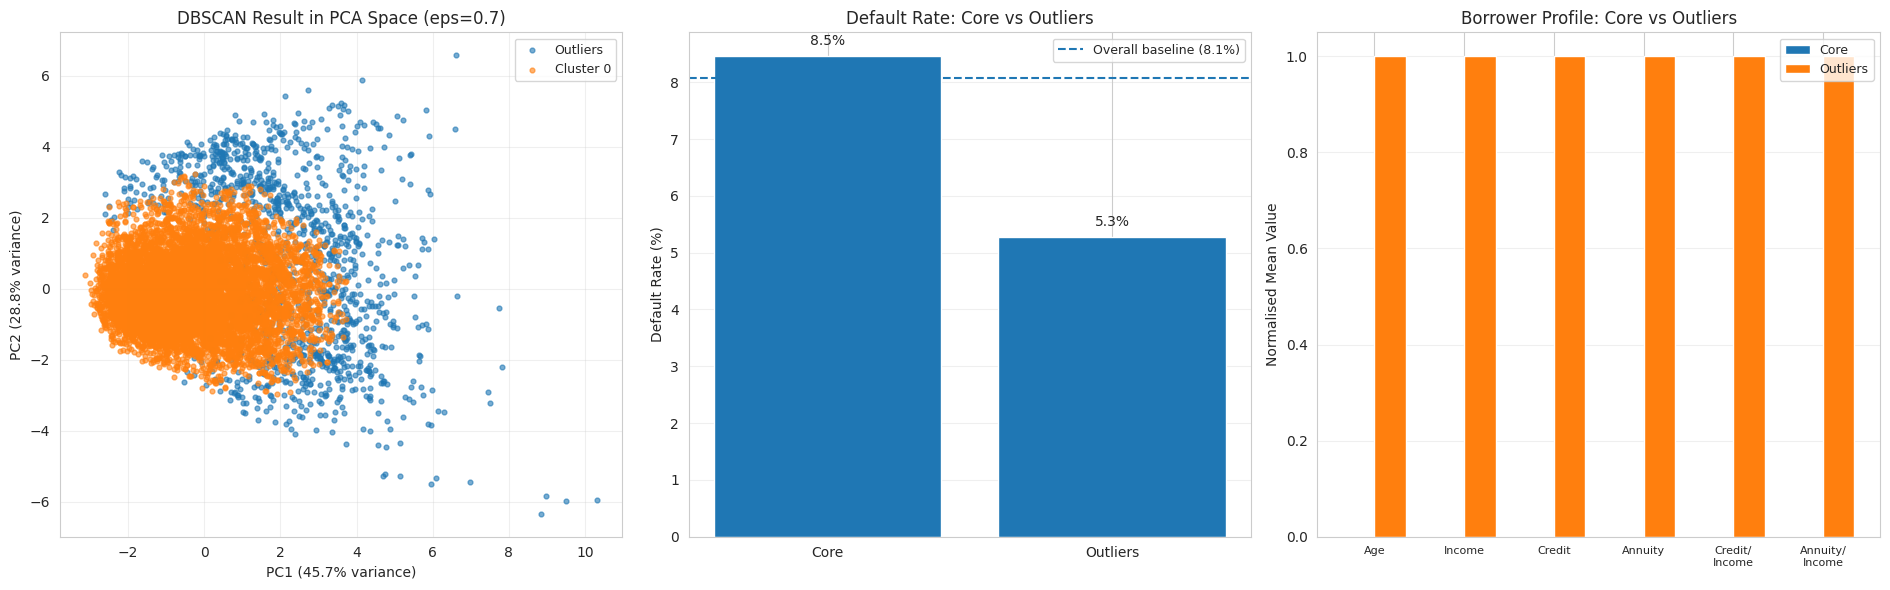

In [41]:
# Visualise DBSCAN results in PCA space and compare default rates.
# This helps translate the clustering output into something meaningful for the credit risk setting.

fig, axes = plt.subplots(1, 3, figsize=(19, 6))

# -------------------------
# Plot 1: PCA scatter plot
# -------------------------
for label in sorted(cluster_sample['DBSCAN_Label'].unique()):
    mask = cluster_sample['DBSCAN_Label'] == label
    label_name = 'Outliers' if label == -1 else f'Cluster {label}'
    axes[0].scatter(
        X_pca[mask, 0],
        X_pca[mask, 1],
        s=12,
        alpha=0.6,
        label=label_name
    )

axes[0].set_title(f'DBSCAN Result in PCA Space (eps={best_eps})')
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0] * 100:.1f}% variance)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1] * 100:.1f}% variance)')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# ----------------------------------------
# Plot 2: Default rate for core vs outliers
# ----------------------------------------
default_by_group = cluster_sample.groupby('Group')['TARGET'].mean() * 100
overall_default = cluster_sample['TARGET'].mean() * 100

bars = axes[1].bar(default_by_group.index, default_by_group.values)
axes[1].axhline(
    overall_default,
    linestyle='--',
    linewidth=1.5,
    label=f'Overall baseline ({overall_default:.1f}%)'
)

for bar, value in zip(bars, default_by_group.values):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.2,
        f'{value:.1f}%',
        ha='center'
    )

axes[1].set_title('Default Rate: Core vs Outliers')
axes[1].set_ylabel('Default Rate (%)')
axes[1].legend(fontsize=9)
axes[1].grid(axis='y', alpha=0.3)

# ----------------------------------------
# Plot 3: Normalised feature profile
# ----------------------------------------
profile_means = cluster_sample.groupby('Group')[clust_features].mean()

# Min-max normalisation for plotting only
profile_norm = (profile_means - profile_means.min()) / (profile_means.max() - profile_means.min())

x = np.arange(len(clust_features))
width = 0.35

axes[2].bar(x - width / 2, profile_norm.loc['Core'], width, label='Core')
axes[2].bar(x + width / 2, profile_norm.loc['Outliers'], width, label='Outliers')

axes[2].set_xticks(x)
axes[2].set_xticklabels([
    'Age',
    'Income',
    'Credit',
    'Annuity',
    'Credit/\nIncome',
    'Annuity/\nIncome'
], fontsize=8)
axes[2].set_ylabel('Normalised Mean Value')
axes[2].set_title('Borrower Profile: Core vs Outliers')
axes[2].legend(fontsize=9)
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [42]:
# Profile summary for interpretation
# This table shows how the core group and outlier group differ on the selected features
# and whether their default rates differ.

profile_table = cluster_sample.groupby('Group')[clust_features + ['TARGET']].mean().round(3)
profile_table['Count'] = cluster_sample.groupby('Group').size()
profile_table['Default_Rate_%'] = (profile_table['TARGET'] * 100).round(2)
profile_table = profile_table.drop(columns=['TARGET'])

print("Core vs Outlier Profile Summary")
display(profile_table)

print("Detailed default rate comparison")
print(f"Core default rate:     {cluster_sample[cluster_sample['Group'] == 'Core']['TARGET'].mean() * 100:.2f}%")
print(f"Outlier default rate:  {cluster_sample[cluster_sample['Group'] == 'Outliers']['TARGET'].mean() * 100:.2f}%")
print(f"Overall default rate:  {cluster_sample['TARGET'].mean() * 100:.2f}%")

Core vs Outlier Profile Summary


,AGE_YEARS,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,CREDIT_INCOME_RATIO,ANNUITY_INCOME_RATIO,Count,Default_Rate_%
Group,,,,,,,,
Core,43.685,154806.162,535731.864,24256.432,3.669,0.169,8787,8.5
Outliers,44.961,245321.677,1080565.831,48597.288,6.231,0.278,1213,5.3


Detailed default rate comparison
Core default rate:     8.46%
Outlier default rate:  5.28%
Overall default rate:  8.07%


## Task 6 Discussion: DBSCAN clustering

### Key findings
DBSCAN was applied to six borrower profile variables after scaling and sampling 10,000 records. Multiple eps values were tested to evaluate whether the dataset contained meaningful density-based clusters.

The results showed that the data did not form clear and stable density-separated subclusters. Instead, DBSCAN consistently produced one large dense cluster along with a smaller group of noise points. This indicates that borrower financial profiles in this dataset form a continuous distribution rather than naturally separated groups.

Therefore, DBSCAN was interpreted primarily as an outlier detection method rather than a segmentation method.

### Outlier vs core comparison
The selected model (eps = 0.7) identified:
- 87.9% of applicants as core borrowers
- 12.1% of applicants as outliers

Interestingly, the outlier group had a lower default rate (5.28%) compared to the core group (8.46%) and the overall baseline (8.07%).

### Business interpretation
This result suggests that unusual borrower profiles are not necessarily higher risk. In fact, the outliers appear to represent applicants with stronger financial capacity.

From the profile comparison:
- Outliers have significantly higher income
- Outliers take larger loans
- Outliers have higher credit-to-income and annuity-to-income ratios

This indicates that the outliers likely represent high-income borrowers taking larger loans, rather than financially distressed applicants.

From a business perspective:
- These outliers should not automatically be treated as risky
- Instead, they may represent premium or high-value customers
- Risk assessment should consider proportional measures rather than absolute loan size

### Why DBSCAN was still useful
Although DBSCAN did not produce multiple clusters, it was still valuable because it identified a distinct group of applicants with different financial characteristics and lower default rates.

Unlike K-Means or Hierarchical Clustering, DBSCAN can identify noise points explicitly. In this dataset, that capability revealed a meaningful distinction between typical borrowers and financially stronger outliers.

### Limitations
DBSCAN is sensitive to parameter selection, especially eps and min_samples. Different values can change the number of outliers significantly. Additionally, the analysis used only six selected variables, so it does not capture the full complexity of borrower risk.

The PCA visualisation is a simplified 2D representation and does not fully reflect the structure of the original six-dimensional feature space.

### Overall conclusion
DBSCAN did not reveal strong natural borrower segments in this dataset. However, it successfully identified a group of unusual applicants who differ from the majority and exhibit lower default risk. This demonstrates that DBSCAN can provide useful insights even when traditional clustering is not effective, particularly for identifying atypical but potentially valuable customer segments.

# Task-7: Project specific and final results

## Task 7: Overall Findings and Conclusion

### Summary of approaches
This project applied three data mining techniques on the Home Credit Default Risk dataset:

- Association Rule Mining (Apriori) on housing and employment features  
- Classification using Gaussian Naive Bayes and Linear SVM  
- Clustering using DBSCAN on borrower financial profile variables  

Each method provided a different perspective on borrower risk.

---

### Key insights from ARM
Apriori revealed interpretable patterns linking borrower characteristics such as income type, housing, and occupation to default behaviour.

These rules are valuable because they highlight specific borrower profiles associated with higher default likelihood. From a business perspective, they can support rule-based screening and policy decisions.

---

### Key insights from classification
The classification models demonstrated that default risk can be predicted using the available features.

- ROC-AUC showed that both models can effectively rank applicants by risk  
- F1 score for the default class highlighted the ability to detect high-risk borrowers  

Naive Bayes provided a fast baseline, while Linear SVM performed better in handling high-dimensional data.

These models are useful for prioritising applications and supporting automated credit decisions.

---

### Key insights from clustering
DBSCAN did not identify clear and stable density-separated borrower segments. Instead, the dataset formed a continuous distribution of financial profiles.

However, DBSCAN successfully identified a group of outlier applicants, representing approximately 12.1% of the sample.

Interestingly, these outliers had a lower default rate (5.28%) compared to the core population (8.46%) and the overall baseline (8.07%).

Profile analysis showed that outliers tend to have:
- higher income  
- larger credit amounts  
- higher credit-to-income and annuity-to-income ratios  

This suggests that the outliers represent financially stronger borrowers rather than high-risk individuals.

---

### Comparison of methods
Each method contributed differently:

- ARM provided interpretable rules explaining relationships between features and default  
- Classification provided predictive models for identifying high-risk applicants  
- DBSCAN revealed structural insights and identified atypical borrower profiles  

Together, these methods provided a more complete understanding of the dataset.

---

### Business implications
From a credit risk perspective:

- Rule-based insights can guide policy design and explain risk factors  
- Predictive models can improve approval decisions and prioritisation  
- Outlier detection can identify unusual but potentially valuable customers  

Importantly, the results show that high loan amounts alone do not indicate higher risk. Relative financial capacity and repayment ability are more important.

---

### Limitations
- The dataset is highly imbalanced, which makes default prediction challenging  
- Only selected features were used in each task  
- DBSCAN is sensitive to parameter settings and did not produce strong segmentation  

---

### Final conclusion
This project demonstrates that combining multiple data mining techniques leads to deeper insights than relying on a single approach.

While classification models are most useful for prediction, ARM and DBSCAN provide valuable interpretability and structural understanding. In particular, DBSCAN revealed that unusual borrower profiles are not necessarily risky, highlighting the importance of careful and context-aware credit assessment.